### Imports

In [1]:
!pip install xarray rioxarray geopandas matplotlib numpy netCDF4 scipy
import os
import numpy as np
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

### Load and Clip

In [2]:
# Main project folder
BASE_DIR = "/Users/mdmustafizurrahmanmunna/Desktop/Geospatial"

# Climate data
TMAX_FILE = os.path.join(BASE_DIR, "TerraClimate_tmax_2025.nc")
PPT_FILE  = os.path.join(BASE_DIR, "TerraClimate_ppt_2025.nc")

# Natural Earth shapefile
BORDERS = os.path.join(
    BASE_DIR,
    "ne_10m_admin_0_countries",
    "ne_10m_admin_0_countries.shp"
)

In [3]:
world = gpd.read_file(BORDERS)
world.head()
print(world.crs)
print(len(world))

EPSG:4326
258


In [4]:
import xarray as xr

# File paths
tmax_file = "/Users/mdmustafizurrahmanmunna/Desktop/Geospatial/TerraClimate_tmax_2025.nc"
ppt_file = "/Users/mdmustafizurrahmanmunna/Desktop/Geospatial/TerraClimate_ppt_2025.nc"

# Open the datasets
tmax_ds = xr.open_dataset(tmax_file)
ppt_ds = xr.open_dataset(ppt_file)

In [5]:
tmax_ds = xr.open_dataset(TMAX_FILE, engine="netcdf4")
type(tmax_ds)

xarray.core.dataset.Dataset

In [6]:
print(tmax_ds.dims)
print(ppt_ds.dims)

FrozenMappingWarningOnValuesAccess({'time': 12, 'lat': 4320, 'lon': 8640, 'crs': 1})
FrozenMappingWarningOnValuesAccess({'time': 12, 'lat': 4320, 'lon': 8640, 'crs': 1})


In [7]:
tmax_da = xr.open_dataset(TMAX_FILE, engine="netcdf4")["tmax"].mean("time")
ppt_da = xr.open_dataset(PPT_FILE, engine="netcdf4")["ppt"].sum("time")

tmax_da = tmax_da.rio.write_crs("EPSG:4326")
ppt_da  = ppt_da.rio.write_crs("EPSG:4326")

In [8]:
REGION = ["Africa"]

world = gpd.read_file(BORDERS)

if isinstance(REGION, list):
    region_gdf = world[world["NAME"].isin(REGION)]
    print(f"Countries: {REGION}")

elif REGION == "World":
    region_gdf = world.copy()
    print("Region: World")

else:
    region_gdf = world[world["CONTINENT"] == REGION]
    print(f"Continent: {REGION} — {len(region_gdf)} countries")

Countries: ['Africa']


In [9]:
# Load the Natural Earth boundaries
world = gpd.read_file(BORDERS)

# Choose a study area
REGION = "Africa"    

# Select the region
if REGION == "World":
    region_gdf = world.copy()

elif isinstance(REGION, list):
    region_gdf = world[world["ADMIN"].isin(REGION)]

else:
    region_gdf = world[world["CONTINENT"] == REGION]

print(region_gdf.head())
print(f"Selected {len(region_gdf)} countries")

         featurecla  scalerank  LABELRANK   SOVEREIGNT SOV_A3  ADM0_DIF  \
13  Admin-0 country          0          2     Ethiopia    ETH         0   
14  Admin-0 country          0          3  South Sudan    SDS         0   
15  Admin-0 country          0          6      Somalia    SOM         0   
16  Admin-0 country          0          2        Kenya    KEN         0   
17  Admin-0 country          0          6       Malawi    MWI         0   

    LEVEL               TYPE TLC        ADMIN  ... FCLASS_TR  FCLASS_ID  \
13      2  Sovereign country   1     Ethiopia  ...      None       None   
14      2  Sovereign country   1  South Sudan  ...      None       None   
15      2  Sovereign country   1      Somalia  ...      None       None   
16      2  Sovereign country   1        Kenya  ...      None       None   
17      2  Sovereign country   1       Malawi  ...      None       None   

   FCLASS_PL FCLASS_GR  FCLASS_IT FCLASS_NL FCLASS_SE  FCLASS_BD FCLASS_UA  \
13      None      No

In [10]:
# Clip both rasters to the region boundary
tmax_clip = tmax_da.rio.clip(region_gdf.geometry, region_gdf.crs, drop=True)
ppt_clip  = ppt_da.rio.clip(region_gdf.geometry,  region_gdf.crs, drop=True)

print(f"Grid size: {tmax_clip.shape}")
print(f"Temp:   {float(tmax_clip.min()):.1f}°C → {float(tmax_clip.max()):.1f}°C")
print(f"Precip: {float(ppt_clip.min()):.0f} → {float(ppt_clip.max()):.0f} mm/yr")

Grid size: (2023, 1843)
Temp:   4.9°C → 40.5°C
Precip: 0 → 5716 mm/yr


### Classify & Smooth

Corner check:
Cold & Dry  (Index 0)  : (1.0, 0.9529411764705882, 0.8392156862745098)  -> Light Grey
Hot  & Dry  (Index 3)  : (1.0, 0.30196078431372547, 0.42745098039215684)  -> Orange
Cold & Wet  (Index 12) : (1.0, 0.8235294117647058, 0.30196078431372547) -> Teal / Blue
Hot  & Wet  (Index 15) : (0.7098039215686275, 0.08627450980392157, 0.11372549019607843) -> Dark Green


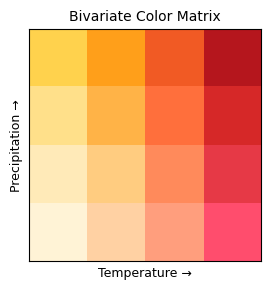

In [12]:
# 4×4 Bivariate Color Palette
PALETTE = [
    ["#FFD24D", "#FF9F1A", "#F15A24", "#B5161D"],  # High precipitation
    ["#FFE08A", "#FFB347", "#FF6F3C", "#D62828"],
    ["#FFEAB8", "#FFCC80", "#FF8A5B", "#E63946"],
    ["#FFF3D6", "#FFD1A3", "#FF9E7D", "#FF4D6D"]   # Low precipitation
]
# Number of classes
N = len(PALETTE)
def hex_to_rgb(h):
    """
    Convert a hex color string to a normalized (r, g, b) tuple.
    """
    h = h.lstrip("#")
    return tuple(int(h[i:i+2], 16) / 255.0 for i in (0, 2, 4))

# Build the flat colormap
# Order must match:
# bi_grid = ppt_quantile * N + temp_quantile
flat_colors = [
    hex_to_rgb(PALETTE[N - 1 - pq][tq])
    for pq in range(N)
    for tq in range(N)
]
# Create matplotlib colormap
cmap = mcolors.ListedColormap(flat_colors)
# Build legend matrix
legend_grid = np.array([
    [
        hex_to_rgb(PALETTE[N - 1 - row][col])
        for col in range(N)
    ]
    for row in range(N)
])
# Check color order
print("Corner check:")
print(f"Cold & Dry  (Index 0)  : {flat_colors[0]}  -> Light Grey")
print(f"Hot  & Dry  (Index 3)  : {flat_colors[3]}  -> Orange")
print(f"Cold & Wet  (Index 12) : {flat_colors[12]} -> Teal / Blue")
print(f"Hot  & Wet  (Index 15) : {flat_colors[15]} -> Dark Green")
# Preview the bivariate palette
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(
    legend_grid,
    origin="lower",
    aspect="equal"
)
ax.set_xlabel("Temperature →", fontsize=9)
ax.set_ylabel("Precipitation →", fontsize=9)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Bivariate Color Matrix", fontsize=10)
plt.tight_layout()
plt.show()

In [13]:
def qbin(arr, breaks):
    """Assign values to quantile bins [0, N-1]."""
    return np.clip(np.digitize(arr, breaks[1:-1]), 0, len(breaks) - 2)

# Smooth the raw rasters first, then reclassify (smoothing then classifying gives cleaner zone boundaries than classifying then smoothing)
nan_mask = np.isnan(tmax_clip.values) | np.isnan(ppt_clip.values)

In [14]:
# Number of classes for the bivariate map
N = 4
# Temperature percentile breaks
TEMP_BREAKS = [0, 20, 50, 80, 100]
# Precipitation percentile breaks
PPT_BREAKS = [0, 30, 60, 85, 100]

# Gaussian smoothing strength
SIGMA = 1.2

In [15]:
temp_vals = tmax_clip.values.flatten()
ppt_vals = ppt_clip.values.flatten()
valid = ~np.isnan(temp_vals) & ~np.isnan(ppt_vals)
t_breaks = np.nanpercentile(temp_vals[valid], TEMP_BREAKS)
p_breaks = np.nanpercentile(ppt_vals[valid], PPT_BREAKS)
print(t_breaks)
print(p_breaks)

[ 4.85       28.625      31.79166667 35.7        40.525     ]
[   0.    70.5  675.1 1160.9 5716.5]


In [16]:
t_breaks = np.nanpercentile(temp_vals[valid], TEMP_BREAKS)
print(type(tmax_clip))
print(type(ppt_clip))
print(TEMP_BREAKS)
print(PPT_BREAKS)

<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
[0, 20, 50, 80, 100]
[0, 30, 60, 85, 100]


In [17]:
def smooth(arr):
    """Fill NaN with mean, apply Gaussian blur, return smoothed array."""
    filled = np.where(nan_mask, np.nanmean(arr), arr)
    return gaussian_filter(filled, sigma=SIGMA)

ts = smooth(tmax_clip.values).flatten()
ps = smooth(ppt_clip.values).flatten()
vm = ~nan_mask.flatten()

tq = np.full(ts.shape, -1, dtype=int)
pq = np.full(ps.shape, -1, dtype=int)
tq[vm] = qbin(ts[vm], t_breaks)
pq[vm] = qbin(ps[vm], p_breaks)

# Combined bivariate class — single integer per pixel
bi_grid = np.where(~nan_mask,
                   pq.reshape(nan_mask.shape) * N + tq.reshape(nan_mask.shape),
                   np.nan)

print(f"Grid shape: {bi_grid.shape}")
print(f"Value range: {np.nanmin(bi_grid):.0f} → {np.nanmax(bi_grid):.0f}  (expected 0–{N**2-1})")
print(f"Temp breaks:  {[f'{v:.1f}' for v in t_breaks]}")
print(f"Precip breaks: {[f'{v:.0f}' for v in p_breaks]}")

Grid shape: (2023, 1843)
Value range: 0 → 15  (expected 0–15)
Temp breaks:  ['4.9', '28.6', '31.8', '35.7', '40.5']
Precip breaks: ['0', '70', '675', '1161', '5716']


### Plot the Map

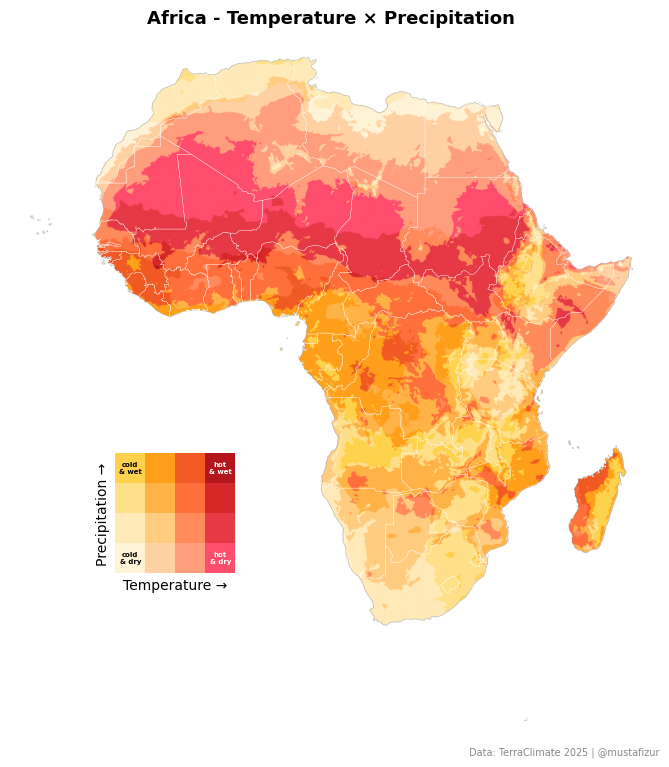

Saved: bivariate_africa.png


In [49]:
def draw_legend(ax, grid_rgb, n, text_color="k", fontsize=6):
    """Draw the 2D color legend with axis labels and corner annotations."""
    ax.imshow(
        grid_rgb,
        origin="lower",
        aspect="equal",
        extent=[0, n, 0, n],
        interpolation="nearest"
    )
    ax.set_xlabel("Temperature →", fontsize=fontsize, color=text_color, labelpad=2)
    ax.set_ylabel("Precipitation →", fontsize=fontsize, color=text_color, labelpad=2)
    ax.set_xticks([])
    ax.set_yticks([])
    # Remove border
    for sp in ax.spines.values():
        sp.set_visible(False)
    # Corner labels
    kw = dict(
        fontsize=fontsize - 1,
        ha="center",
        va="center",
        alpha=0.9,
        linespacing=1.3,
        transform=ax.transData
    )
    ax.text(0.5, 0.5, "cold\n& dry", color="k", **kw)
    ax.text(n - 0.5, 0.5, "hot\n& dry", color="w", **kw)
    ax.text(0.5, n - 0.5, "cold\n& wet", color="w", **kw)
    ax.text(n - 0.5, n - 0.5, "hot\n& wet", color="w", **kw)

# Compute extent and bounds for the map axes
lons = tmax_clip.coords["lon"].values
lats = tmax_clip.coords["lat"].values

extent = [lons.min(), lons.max(), lats.min(), lats.max()]
bounds = region_gdf.total_bounds   # [minx, miny, maxx, maxy]
pad = max(bounds[2] - bounds[0], bounds[3] - bounds[1]) * 0.03

# Build the figure
fig = plt.figure(figsize= (8, 8), facecolor="white")

ax = fig.add_axes(
    [0.1, 0.04, 0.94, 0.88],
    facecolor="white"
)

# Bivariate raster
ax.imshow(
    bi_grid,
    cmap=cmap,
    vmin=0,
    vmax=N**2 - 1,
    extent=extent,
    origin="upper",
    aspect="auto",
    interpolation="bilinear",
    zorder=1
)
# Country borders
region_gdf.boundary.plot(
    ax=ax,
    linewidth=0.2,
    color="white",
    zorder=2
)

# Zoom to the region with a small padding buffer
ax.set_xlim(bounds[0] - pad, bounds[2] + pad)
ax.set_ylim(bounds[1] - pad, bounds[3] + pad)
ax.axis("off")

# Title
title = REGION if isinstance(REGION, str) else ", ".join(REGION)

ax.set_title(
    f"{title} - Temperature × Precipitation",
    color="k",
    fontsize=13,
    fontweight="bold",
    pad=10,
    loc="Center"
)
def draw_legend(ax, legend_grid, N):
    # Draw the color grid
    ax.imshow(legend_grid, origin="lower")
    # Remove ticks
    ax.set_xticks([])
    ax.set_yticks([])
    # Axis labels
    ax.set_xlabel("Temperature →", fontsize=10)
    ax.set_ylabel("Precipitation →", fontsize=10)

    # Corner labels
    ax.text(
        0, 0,
        "cold\n& dry",
        ha="center",
        va="center",
        fontsize=5,
        color="black",
        fontweight="bold"
    )

    ax.text(
        N - 1, 0,
        "hot\n& dry",
        ha="center",
        va="center",
        fontsize=5,
        color="white",
        fontweight="bold"
    )

    ax.text(
        0, N - 1,
        "cold\n& wet",
        ha="center",
        va="center",
        fontsize=5,
        color="black",
        fontweight="bold"
    )

    ax.text(
        N - 1, N - 1,
        "hot\n& wet",
        ha="center",
        va="center",
        fontsize=5,
        color="white",
        fontweight="bold"
    )
    # Remove border
    for spine in ax.spines.values():
        spine.set_visible(False)
# Legend inset
ax_leg = fig.add_axes(
    [0.25, 0.25, 0.25, 0.15],
    facecolor="white"
)
draw_legend(ax_leg, legend_grid, N)
# Data credit
fig.text(
    0.98,
    0.02,
    "Data: TerraClimate 2025 | @mustafizur",
    ha="right",
    va="bottom",
    fontsize=7,
    color="#888888"
)

# Save
fname = title.lower().replace(" ", "_").replace(",", "")

plt.savefig(
    f"bivariate_{fname}.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

print(f"Saved: bivariate_{fname}.png")